### Question-2

In [4]:
#pip install torch torchvision matplotlib scikit-learn pandas

In [5]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

/home/admin1/miniconda/bin/python
2.11.0+cu130
13.0
True
NVIDIA GeForce RTX 5080


### Imports

In [6]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, f1_score

### Set Seed and device

In [7]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),   # conv1
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # conv2
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # conv3
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # conv4
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # conv5
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),# conv6
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
def get_transforms(model_name):
    model_name = model_name.lower()

    if model_name == "customcnn":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.5071, 0.4867, 0.4408),
                                 (0.2675, 0.2565, 0.2761))
        ])

        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5071, 0.4867, 0.4408),
                                 (0.2675, 0.2565, 0.2761))
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406),
                                 (0.229, 0.224, 0.225))
        ])

        test_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406),
                                 (0.229, 0.224, 0.225))
        ])

    return train_transform, test_transform

In [10]:
def get_dataloaders(model_name, batch_size=128, val_ratio=0.1):
    train_transform, test_transform = get_transforms(model_name)

    full_train_dataset = datasets.CIFAR100(
        root="./data",
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR100(
        root="./data",
        train=False,
        download=True,
        transform=test_transform
    )

    val_size = int(len(full_train_dataset) * val_ratio)
    train_size = len(full_train_dataset) - val_size

    train_dataset, val_dataset_temp = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Validation without augmentation
    base_train_for_val = datasets.CIFAR100(
        root="./data",
        train=True,
        download=True,
        transform=test_transform
    )
    val_dataset = torch.utils.data.Subset(base_train_for_val, val_dataset_temp.indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader

In [11]:
def get_model(model_name, num_classes=100, pretrained=True):
    model_name = model_name.lower()

    if model_name == "customcnn":
        return CustomCNN(num_classes=num_classes)

    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        return model

    elif model_name == "vgg19":
        weights = models.VGG19_Weights.DEFAULT if pretrained else None
        model = models.vgg19(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
        return model

    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        return model

    elif model_name == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        return model

    else:
        raise ValueError(f"Unknown model name: {model_name}")

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    return running_loss / total, correct / total, np.array(all_labels), np.array(all_preds)

In [13]:
def compute_multiclass_metrics(y_true, y_pred, num_classes=100):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    TP = 0
    TN = 0
    FP = 0
    FN = 0

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        TP += tp
        TN += tn
        FP += fp
        FN += fn

    accuracy = (y_true == y_pred).mean()
    f1 = f1_score(y_true, y_pred, average="macro")

    return {
        "Accuracy": accuracy,
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
        "F1-score": f1
    }

In [14]:
def train_model(model, model_name, train_loader, val_loader, epochs, lr, weight_decay):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    patience = 8
    patience_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"{model_name} | Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")
        print("-" * 40)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [15]:
def plot_history(history, model_name):
    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss Curve")
    plt.legend()
    plt.show()

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy Curve")
    plt.legend()
    plt.show()

In [16]:
def get_first_conv_weights(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            return module.weight.detach().cpu().numpy()
    raise ValueError("No Conv2d layer found.")

In [17]:
def plot_filters(weights, title, num_filters=2):
    num_filters = min(num_filters, weights.shape[0])

    fig, axes = plt.subplots(1, num_filters, figsize=(4 * num_filters, 4))
    if num_filters == 1:
        axes = [axes]

    for i in range(num_filters):
        w = weights[i]
        w = np.transpose(w, (1, 2, 0))

        w_min, w_max = w.min(), w.max()
        if w_max > w_min:
            w = (w - w_min) / (w_max - w_min)

        axes[i].imshow(w)
        axes[i].set_title(f"Filter {i}")
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### Train Custom CNN

c:\Users\pette\documents\Git_rep\DV2646_DeepML\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CustomCNN | Epoch 1/100
Train Loss: 4.2839, Train Acc: 0.0428
Val Loss:   3.9116, Val Acc:   0.0782
----------------------------------------
CustomCNN | Epoch 2/100
Train Loss: 3.9688, Train Acc: 0.0774
Val Loss:   3.6544, Val Acc:   0.1254
----------------------------------------
CustomCNN | Epoch 3/100
Train Loss: 3.8383, Train Acc: 0.0952
Val Loss:   3.4525, Val Acc:   0.1630
----------------------------------------
CustomCNN | Epoch 4/100
Train Loss: 3.7256, Train Acc: 0.1090
Val Loss:   3.2949, Val Acc:   0.1834
----------------------------------------
CustomCNN | Epoch 5/100
Train Loss: 3.6234, Train Acc: 0.1229
Val Loss:   3.2174, Val Acc:   0.2024
----------------------------------------
CustomCNN | Epoch 6/100
Train Loss: 3.5348, Train Acc: 0.1358
Val Loss:   3.1248, Val Acc:   0.2030
----------------------------------------
CustomCNN | Epoch 7/100
Train Loss: 3.4509, Train Acc: 0.1484
Val Loss:   2.9677, Val Acc:   0.2464
----------------------------------------
CustomCNN | E

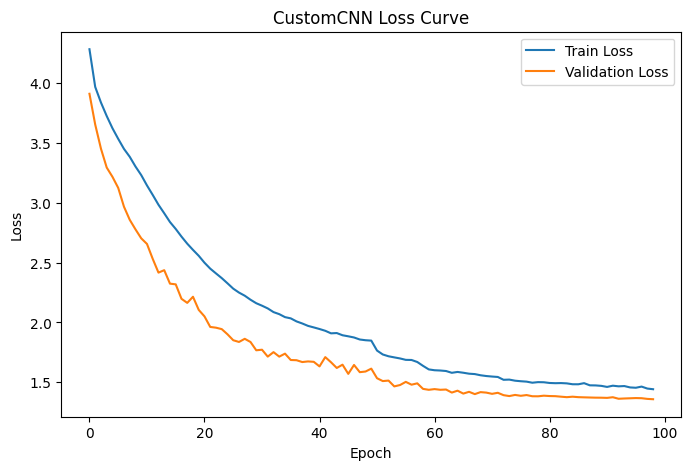

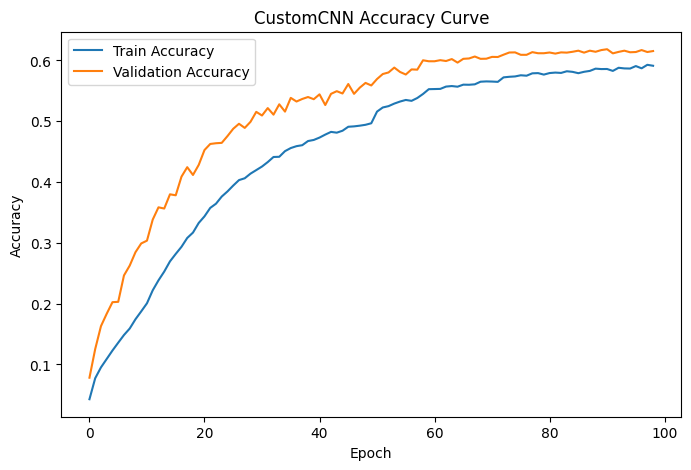

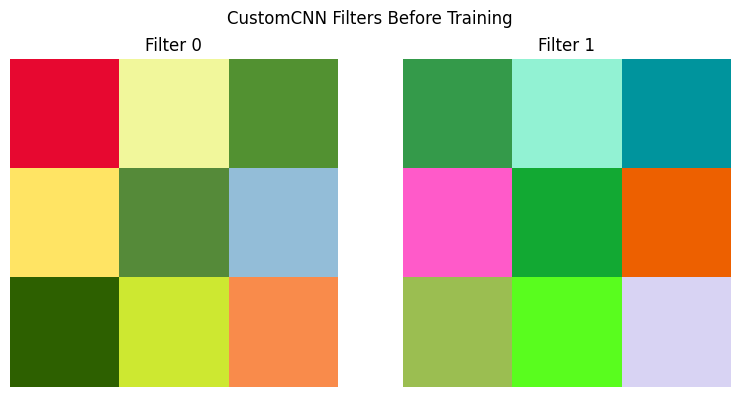

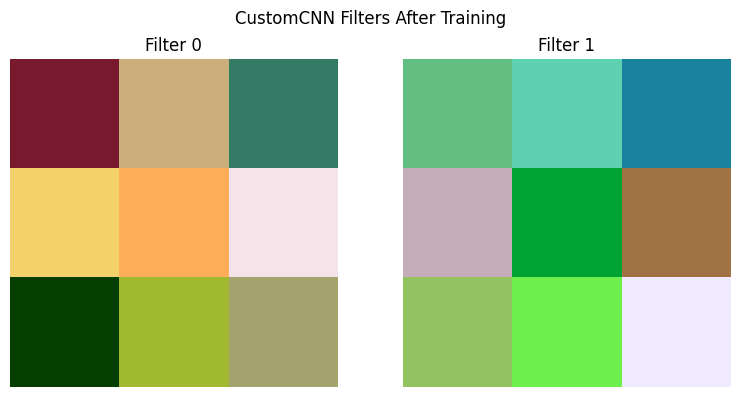

In [30]:
model_name = "CustomCNN"
train_loader, val_loader, test_loader = get_dataloaders(model_name, batch_size=128)

model = get_model(model_name, num_classes=100, pretrained=False).to(device)

weights_before = get_first_conv_weights(model)

model, history = train_model(
    model=model,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-4
)

plot_history(history, model_name)

weights_after = get_first_conv_weights(model)
plot_filters(weights_before, "CustomCNN Filters Before Training", num_filters=2)
plot_filters(weights_after, "CustomCNN Filters After Training", num_filters=2)

In [1]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
metrics_custom = compute_multiclass_metrics(y_true, y_pred, num_classes=100)

print("CustomCNN Test Loss:", test_loss)
print("CustomCNN Test Accuracy:", test_acc)
print(metrics_custom)

NameError: name 'nn' is not defined

#### Pretrained models

In [18]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

import sys
print(sys.executable)
print(sys.version)

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

CUDA available: True
Device: NVIDIA GeForce RTX 5080
/home/admin1/miniconda/bin/python
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:16:10) [GCC 11.2.0]
2.11.0+cu130
13.0
True


c:\Users\pette\documents\Git_rep\DV2646_DeepML\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


ResNet50 | Epoch 1/12
Train Loss: 1.5158, Train Acc: 0.6176
Val Loss:   0.7050, Val Acc:   0.7866
----------------------------------------
ResNet50 | Epoch 2/12
Train Loss: 0.5832, Train Acc: 0.8242
Val Loss:   0.5958, Val Acc:   0.8190
----------------------------------------
ResNet50 | Epoch 3/12
Train Loss: 0.3832, Train Acc: 0.8836
Val Loss:   0.5764, Val Acc:   0.8266
----------------------------------------
ResNet50 | Epoch 4/12
Train Loss: 0.2764, Train Acc: 0.9136
Val Loss:   0.5977, Val Acc:   0.8250
----------------------------------------
ResNet50 | Epoch 5/12
Train Loss: 0.2067, Train Acc: 0.9353
Val Loss:   0.6011, Val Acc:   0.8328
----------------------------------------
ResNet50 | Epoch 6/12
Train Loss: 0.1629, Train Acc: 0.9480
Val Loss:   0.5840, Val Acc:   0.8372
----------------------------------------
ResNet50 | Epoch 7/12
Train Loss: 0.1361, Train Acc: 0.9583
Val Loss:   0.6300, Val Acc:   0.8332
----------------------------------------
ResNet50 | Epoch 8/12
Train

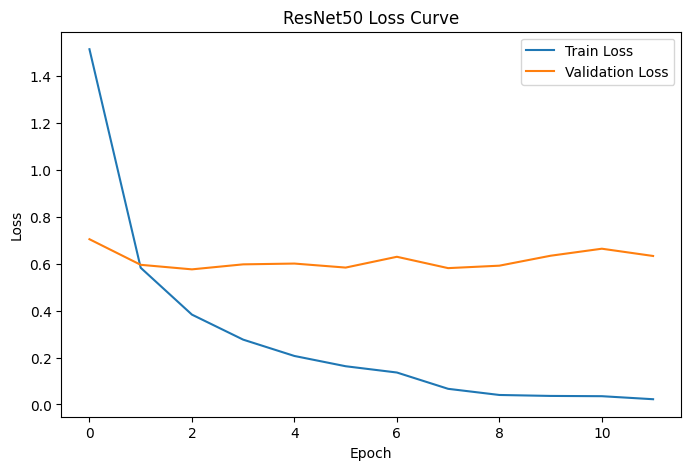

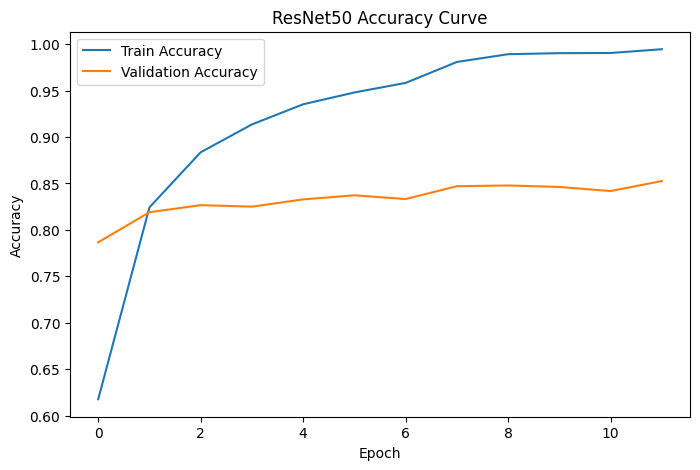

{'Accuracy': np.float64(0.8589), 'TP': 8589, 'TN': 988589, 'FP': 1411, 'FN': 1411, 'F1-score': 0.8591347843076895}


In [17]:
# ResNet50
model_name = "ResNet50"
train_loader, val_loader, test_loader = get_dataloaders(model_name, batch_size=64)

model = get_model(model_name, num_classes=100, pretrained=True).to(device)

model, history_resnet = train_model(
    model=model,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=12,
    lr=1e-4,
    weight_decay=1e-4
)

plot_history(history_resnet, model_name)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
metrics_resnet = compute_multiclass_metrics(y_true, y_pred, num_classes=100)
print(metrics_resnet)

VGG19 | Epoch 1/12
Train Loss: 2.4433, Train Acc: 0.3623
Val Loss:   1.4528, Val Acc:   0.5850
----------------------------------------
VGG19 | Epoch 2/12
Train Loss: 1.7344, Train Acc: 0.5134
Val Loss:   1.2909, Val Acc:   0.6220
----------------------------------------
VGG19 | Epoch 3/12
Train Loss: 1.5385, Train Acc: 0.5613
Val Loss:   1.2348, Val Acc:   0.6394
----------------------------------------
VGG19 | Epoch 4/12
Train Loss: 1.4102, Train Acc: 0.5946
Val Loss:   1.1728, Val Acc:   0.6588
----------------------------------------
VGG19 | Epoch 5/12
Train Loss: 1.3059, Train Acc: 0.6195
Val Loss:   1.1741, Val Acc:   0.6588
----------------------------------------
VGG19 | Epoch 6/12
Train Loss: 1.2246, Train Acc: 0.6439
Val Loss:   1.1487, Val Acc:   0.6728
----------------------------------------
VGG19 | Epoch 7/12
Train Loss: 1.1575, Train Acc: 0.6635
Val Loss:   1.1286, Val Acc:   0.6784
----------------------------------------
VGG19 | Epoch 8/12
Train Loss: 1.0986, Train Acc

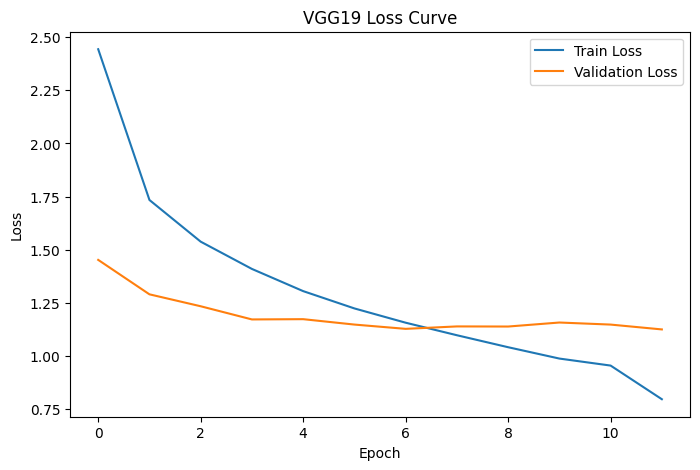

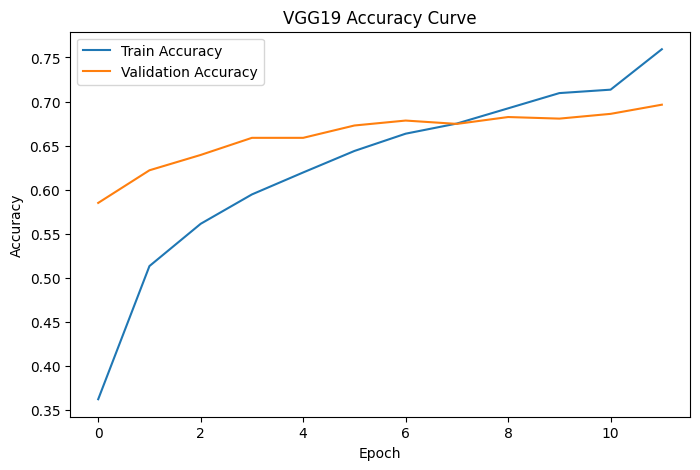

{'Accuracy': np.float64(0.6834), 'TP': 6834, 'TN': 986834, 'FP': 3166, 'FN': 3166, 'F1-score': 0.6828106477815545}


In [20]:
# VGG19
model_name = "VGG19"
train_loader, val_loader, test_loader = get_dataloaders(model_name, batch_size=64)

model = get_model(model_name, num_classes=100, pretrained=True).to(device)

for param in model.features.parameters():
    param.requires_grad = False

model, history_vgg = train_model(
    model=model,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=12,
    lr=1e-4,
    weight_decay=1e-4
)

plot_history(history_vgg, model_name)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
metrics_vgg = compute_multiclass_metrics(y_true, y_pred, num_classes=100)
print(metrics_vgg)

/home/admin1/miniconda/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /home/admin1/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:01<00:00, 29.9MB/s]


DenseNet121 | Epoch 1/12
Train Loss: 1.9652, Train Acc: 0.5526
Val Loss:   0.9509, Val Acc:   0.7386
----------------------------------------
DenseNet121 | Epoch 2/12
Train Loss: 0.8046, Train Acc: 0.7764
Val Loss:   0.7242, Val Acc:   0.7864
----------------------------------------
DenseNet121 | Epoch 3/12
Train Loss: 0.5559, Train Acc: 0.8388
Val Loss:   0.6502, Val Acc:   0.8062
----------------------------------------
DenseNet121 | Epoch 4/12
Train Loss: 0.4105, Train Acc: 0.8791
Val Loss:   0.6378, Val Acc:   0.8096
----------------------------------------
DenseNet121 | Epoch 5/12
Train Loss: 0.3189, Train Acc: 0.9042
Val Loss:   0.6460, Val Acc:   0.8074
----------------------------------------
DenseNet121 | Epoch 6/12
Train Loss: 0.2517, Train Acc: 0.9250
Val Loss:   0.6323, Val Acc:   0.8170
----------------------------------------
DenseNet121 | Epoch 7/12
Train Loss: 0.2069, Train Acc: 0.9374
Val Loss:   0.6547, Val Acc:   0.8132
----------------------------------------
DenseN

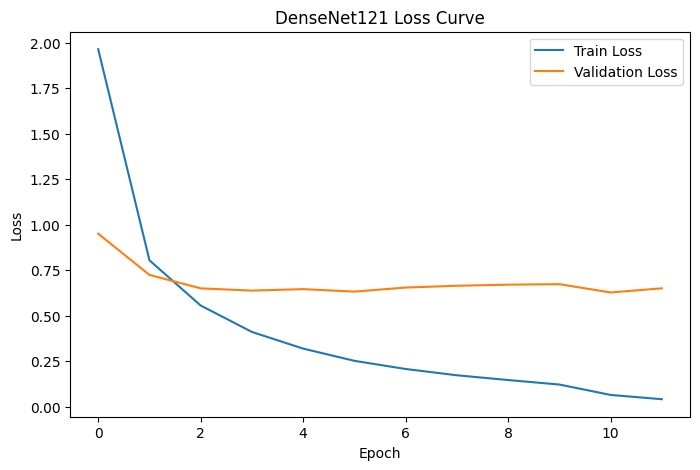

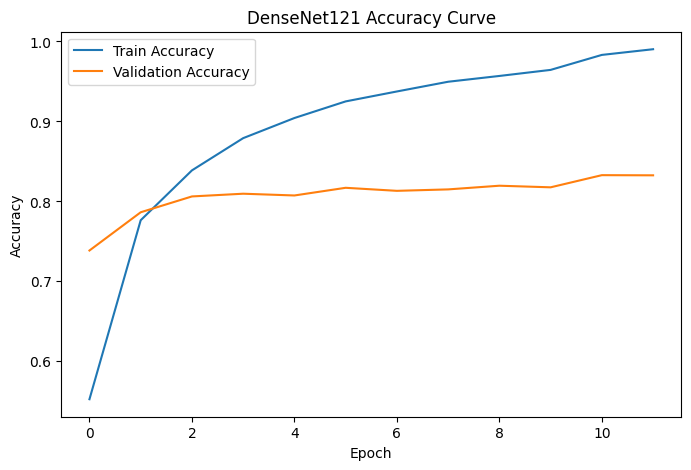

{'Accuracy': np.float64(0.837), 'TP': 8370, 'TN': 988370, 'FP': 1630, 'FN': 1630, 'F1-score': 0.8376242868035001}


In [21]:
# DenseNet121
model_name = "DenseNet121"
train_loader, val_loader, test_loader = get_dataloaders(model_name, batch_size=64)

model = get_model(model_name, num_classes=100, pretrained=True).to(device)

model, history_dense = train_model(
    model=model,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=12,
    lr=1e-4,
    weight_decay=1e-4
)

plot_history(history_dense, model_name)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
metrics_dense = compute_multiclass_metrics(y_true, y_pred, num_classes=100)
print(metrics_dense)

6.1%

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\pette/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


EfficientNet_B0 | Epoch 1/12
Train Loss: 2.1891, Train Acc: 0.5037
Val Loss:   0.8817, Val Acc:   0.7490
----------------------------------------
EfficientNet_B0 | Epoch 2/12
Train Loss: 0.8521, Train Acc: 0.7555
Val Loss:   0.6485, Val Acc:   0.7978
----------------------------------------
EfficientNet_B0 | Epoch 3/12
Train Loss: 0.6196, Train Acc: 0.8146
Val Loss:   0.5636, Val Acc:   0.8268
----------------------------------------
EfficientNet_B0 | Epoch 4/12
Train Loss: 0.4847, Train Acc: 0.8509
Val Loss:   0.5257, Val Acc:   0.8366
----------------------------------------
EfficientNet_B0 | Epoch 5/12
Train Loss: 0.3946, Train Acc: 0.8776
Val Loss:   0.5244, Val Acc:   0.8400
----------------------------------------
EfficientNet_B0 | Epoch 6/12
Train Loss: 0.3220, Train Acc: 0.8988
Val Loss:   0.5149, Val Acc:   0.8438
----------------------------------------
EfficientNet_B0 | Epoch 7/12
Train Loss: 0.2744, Train Acc: 0.9142
Val Loss:   0.5323, Val Acc:   0.8448
-------------------

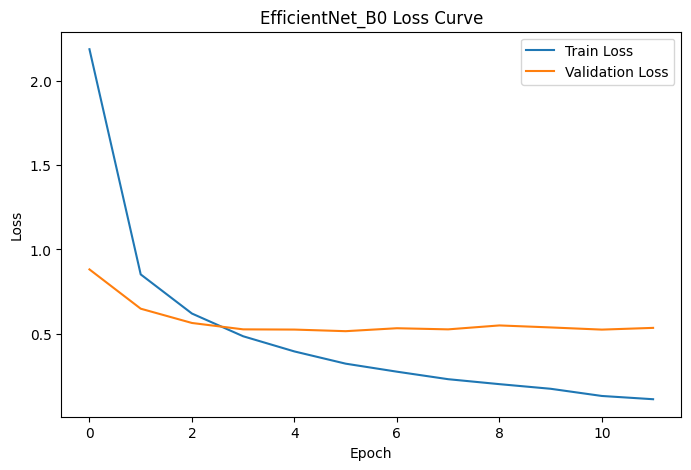

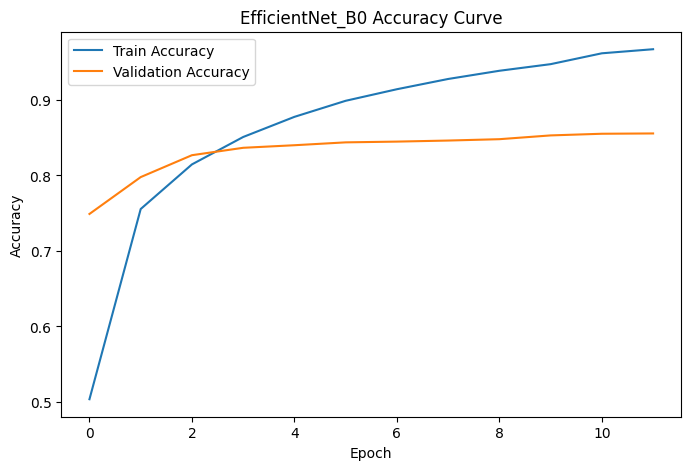

{'Accuracy': np.float64(0.8552), 'TP': 8552, 'TN': 988552, 'FP': 1448, 'FN': 1448, 'F1-score': 0.8554729261726102}


In [20]:
#EfficientNet_B0
model_name = "EfficientNet_B0"
train_loader, val_loader, test_loader = get_dataloaders(model_name, batch_size=64)

model = get_model(model_name, num_classes=100, pretrained=True).to(device)

model, history_eff = train_model(
    model=model,
    model_name=model_name,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=12,
    lr=1e-4,
    weight_decay=1e-4
)

plot_history(history_eff, model_name)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
metrics_eff = compute_multiclass_metrics(y_true, y_pred, num_classes=100)
print(metrics_eff)

#### Plot Results

In [21]:
results = []

metrics_custom["Model"] = "CustomCNN"
metrics_resnet["Model"] = "ResNet50"
metrics_vgg["Model"] = "VGG19"
metrics_dense["Model"] = "DenseNet121"
metrics_eff["Model"] = "EfficientNet_B0"

results.append(metrics_custom)
results.append(metrics_resnet)
results.append(metrics_vgg)
results.append(metrics_dense)
results.append(metrics_eff)

df_results = pd.DataFrame(results)
df_results = df_results[["Model", "Accuracy", "TP", "TN", "FP", "FN", "F1-score"]]
df_results

NameError: name 'metrics_custom' is not defined

In [ ]:
df_results.to_csv("q2_results_table.csv", index=False)